# 01 — Phân tích khám phá dữ liệu

**Bài toán:** dự đoán `Loan Sanction Amount (USD)` cho hồ sơ đã qua bước đủ điều kiện vay.

Notebook này không giả định trước target sạch. Mọi quyết định loại dữ liệu, chọn phạm vi regression và đánh giá policy lịch sử đều dựa trên kết quả tính trực tiếp bên dưới.

In [1]:
from pathlib import Path
import os, sys, json, warnings

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
os.environ["MPLCONFIGDIR"] = str(ROOT / ".matplotlib")
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")

TRAIN_PATH = ROOT / "data" / "train.csv"
TEST_PATH = ROOT / "data" / "test.csv"
TARGET = "Loan Sanction Amount (USD)"
REQUEST = "Loan Amount Request (USD)"
RANDOM_STATE = 42

df_raw = pd.read_csv(TRAIN_PATH)
df_external = pd.read_csv(TEST_PATH)
print(f"Train: {df_raw.shape[0]:,} dòng x {df_raw.shape[1]} cột")
print(f"Test ngoài: {df_external.shape[0]:,} dòng x {df_external.shape[1]} cột")

Train: 30,000 dòng x 24 cột
Test ngoài: 20,000 dòng x 23 cột


## 1. Cấu trúc và chất lượng dữ liệu

In [2]:
quality = pd.DataFrame({
    "dtype": df_raw.dtypes.astype(str),
    "missing": df_raw.isna().sum(),
    "missing_pct": df_raw.isna().mean() * 100,
    "n_unique": df_raw.nunique(dropna=False),
}).sort_values(["missing_pct", "n_unique"], ascending=[False, False])
display(quality)

print(f"Số Customer ID trùng: {df_raw['Customer ID'].duplicated().sum():,}")
print(f"Số dòng trùng hoàn toàn: {df_raw.duplicated().sum():,}")
print(f"Target có trong test ngoài: {TARGET in df_external.columns}")

,dtype,missing,missing_pct,n_unique
Type of Employment,object,7270,24.233,19
Property Age,float64,4850,16.167,24180
Income (USD),float64,4576,15.253,24430
Dependents,float64,2493,8.310,11
Credit Score,float64,1703,5.677,17587
Income Stability,object,1683,5.610,3
Has Active Credit Card,object,1566,5.220,4
Property Location,object,356,1.187,4
Loan Sanction Amount (USD),float64,340,1.133,21451
Current Loan Expenses (USD),float64,172,0.573,24042


Số Customer ID trùng: 0
Số dòng trùng hoàn toàn: 0
Target có trong test ngoài: False


In [3]:
numeric_cols = df_raw.select_dtypes(include=np.number).columns
sentinel_report = pd.DataFrame({
    "negative": [(df_raw[c] < 0).sum() for c in numeric_cols],
    "minus_999": [(df_raw[c] == -999).sum() for c in numeric_cols],
    "zero": [(df_raw[c] == 0).sum() for c in numeric_cols],
}, index=numeric_cols)
display(sentinel_report[(sentinel_report != 0).any(axis=1)])

,negative,minus_999,zero
Current Loan Expenses (USD),177,177,0
No. of Defaults,0,0,24182
Co-Applicant,168,168,4316
Property Price,352,352,0
Loan Sanction Amount (USD),338,338,7865


## 2. Audit target và xác định population cho regression

,Số hồ sơ,Tỷ lệ
Trạng thái target,,
Dương,21457,0.715
Bằng 0,7865,0.262
Thiếu,340,0.011
Sentinel -999,338,0.011


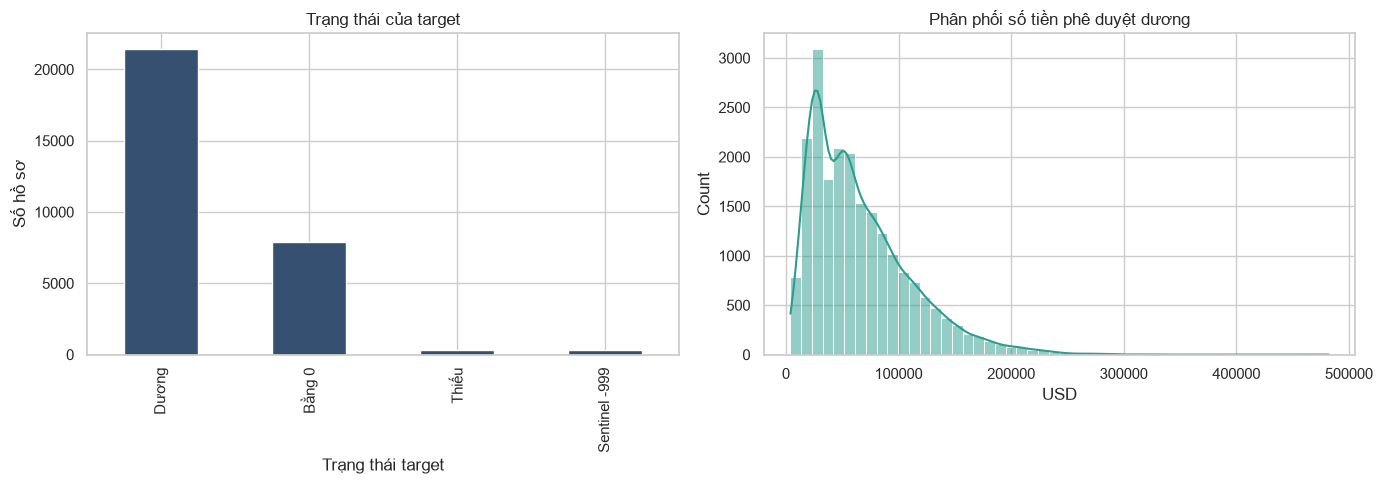

,Giá trị
count,"21,457.000"
mean,"65,881.398"
std,"44,858.650"
min,"4,023.180"
1%,"8,421.390"
5%,"15,113.568"
25%,"30,310.860"
50%,"55,191.660"
75%,"89,126.820"
95%,"152,916.618"


In [4]:
y = pd.to_numeric(df_raw[TARGET], errors="coerce")
target_state = pd.Series(
    np.select(
        [y.isna(), y.eq(-999), y.eq(0), y.gt(0)],
        ["Thiếu", "Sentinel -999", "Bằng 0", "Dương"],
        default="Âm khác",
    ),
    name="Trạng thái target",
)
state_table = target_state.value_counts().to_frame("Số hồ sơ")
state_table["Tỷ lệ"] = state_table["Số hồ sơ"] / len(df_raw)
display(state_table)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
state_table["Số hồ sơ"].plot.bar(ax=axes[0], color="#355070")
axes[0].set_title("Trạng thái của target")
axes[0].set_ylabel("Số hồ sơ")

positive_target = y[y > 0]
sns.histplot(positive_target, bins=50, kde=True, ax=axes[1], color="#2a9d8f")
axes[1].set_title("Phân phối số tiền phê duyệt dương")
axes[1].set_xlabel("USD")
plt.tight_layout()
plt.show()

display(positive_target.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_frame("Giá trị"))

In [5]:
n_positive = int((y > 0).sum())
n_zero = int((y == 0).sum())
n_invalid = int(y.isna().sum() + (y < 0).sum())
display(Markdown(f"""
### Kết luận phạm vi

- Có **{n_positive:,}** hồ sơ mang số tiền phê duyệt dương và phù hợp với regression.
- Có **{n_zero:,}** hồ sơ bằng 0. Không có data dictionary đủ mạnh để khẳng định đây là hồ sơ bị từ chối, nhưng chúng không thuộc cùng cơ chế sinh target với nhóm dương.
- Có **{n_invalid:,}** target thiếu hoặc âm; `-999` thể hiện sentinel chứ không phải số tiền thực.
- Để giữ bài toán thuần regression, mô hình chính chỉ học trên hồ sơ có target dương. Hệ thống vì vậy áp dụng **sau bước pre-qualification**, không quyết định duyệt hay từ chối.
"""))


### Kết luận phạm vi

- Có **21,457** hồ sơ mang số tiền phê duyệt dương và phù hợp với regression.
- Có **7,865** hồ sơ bằng 0. Không có data dictionary đủ mạnh để khẳng định đây là hồ sơ bị từ chối, nhưng chúng không thuộc cùng cơ chế sinh target với nhóm dương.
- Có **678** target thiếu hoặc âm; `-999` thể hiện sentinel chứ không phải số tiền thực.
- Để giữ bài toán thuần regression, mô hình chính chỉ học trên hồ sơ có target dương. Hệ thống vì vậy áp dụng **sau bước pre-qualification**, không quyết định duyệt hay từ chối.


## 3. Số tiền yêu cầu và quy tắc phê duyệt lịch sử

,Số hồ sơ,Tỷ lệ hồ sơ
RatioRounded,,
0.650,5053,0.235
0.700,8625,0.402
0.750,3852,0.180
0.800,3724,0.174
0.850,69,0.003
0.900,79,0.004
1.000,55,0.003


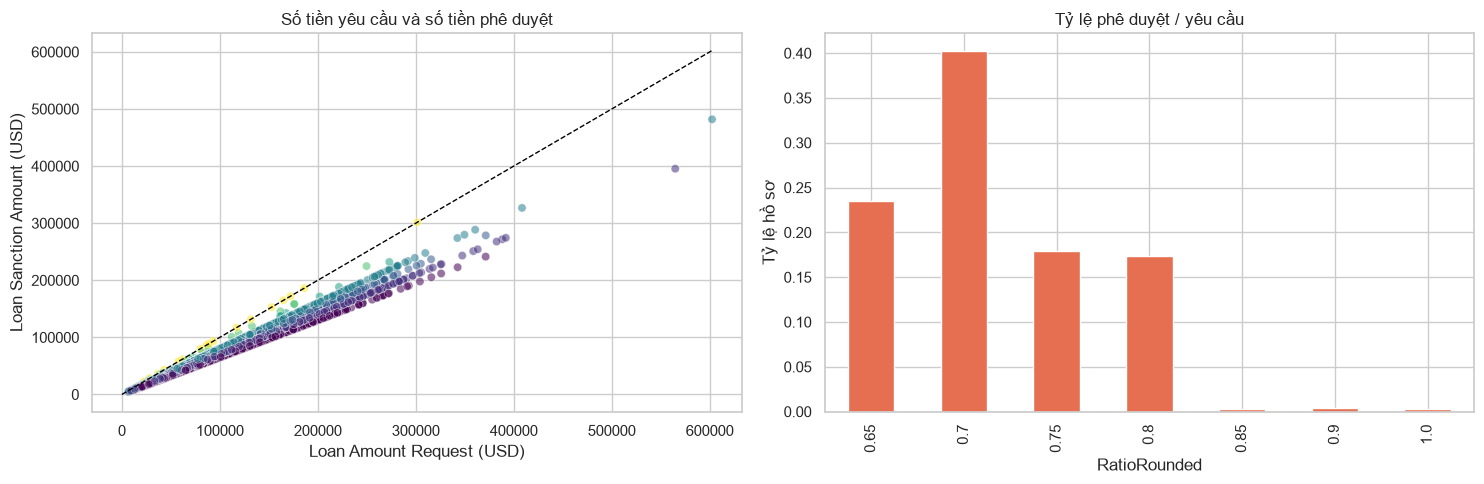

In [6]:
positive = df_raw.loc[y > 0].copy()
positive["SanctionRatio"] = positive[TARGET] / positive[REQUEST]
positive["RatioRounded"] = positive["SanctionRatio"].round(2)

ratio_table = positive["RatioRounded"].value_counts().sort_index().to_frame("Số hồ sơ")
ratio_table["Tỷ lệ hồ sơ"] = ratio_table["Số hồ sơ"] / len(positive)
display(ratio_table)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sample = positive.sample(min(5000, len(positive)), random_state=RANDOM_STATE)
sns.scatterplot(data=sample, x=REQUEST, y=TARGET, hue="RatioRounded", palette="viridis", alpha=.55, ax=axes[0], legend=False)
limit = max(sample[REQUEST].max(), sample[TARGET].max())
axes[0].plot([0, limit], [0, limit], "--", color="black", linewidth=1)
axes[0].set_title("Số tiền yêu cầu và số tiền phê duyệt")

ratio_table["Tỷ lệ hồ sơ"].plot.bar(ax=axes[1], color="#e76f51")
axes[1].set_title("Tỷ lệ phê duyệt / yêu cầu")
axes[1].set_ylabel("Tỷ lệ hồ sơ")
plt.tight_layout()
plt.show()

In [7]:
top_ratios = ratio_table.sort_values("Số hồ sơ", ascending=False).head(4)
share_top = top_ratios["Tỷ lệ hồ sơ"].sum()
baseline_70_mae = np.mean(np.abs(positive[TARGET] - 0.70 * positive[REQUEST]))
target_request_corr = positive[[TARGET, REQUEST]].corr().iloc[0, 1]
display(Markdown(f"""
### Nhận xét về policy lịch sử

- Bốn tỷ lệ phổ biến nhất là {', '.join(f'{idx:.0%}' for idx in top_ratios.index)} và bao phủ **{share_top:.1%}** nhóm target dương.
- Tương quan giữa số tiền yêu cầu và số tiền phê duyệt là **{target_request_corr:.3f}**.
- Chỉ dùng quy tắc `70% × số tiền yêu cầu` đã có MAE **{baseline_70_mae:,.0f} USD** trên toàn bộ nhóm dương.
- Vì target có cấu trúc policy rời rạc, baseline 70% là đối thủ thực tế bắt buộc. Một mô hình phức tạp không vượt baseline này sẽ không có giá trị triển khai.
"""))


### Nhận xét về policy lịch sử

- Bốn tỷ lệ phổ biến nhất là 70%, 65%, 75%, 80% và bao phủ **99.1%** nhóm target dương.
- Tương quan giữa số tiền yêu cầu và số tiền phê duyệt là **0.991**.
- Chỉ dùng quy tắc `70% × số tiền yêu cầu` đã có MAE **3,808 USD** trên toàn bộ nhóm dương.
- Vì target có cấu trúc policy rời rạc, baseline 70% là đối thủ thực tế bắt buộc. Một mô hình phức tạp không vượt baseline này sẽ không có giá trị triển khai.


## 4. Quan hệ với hồ sơ tài chính và tín dụng

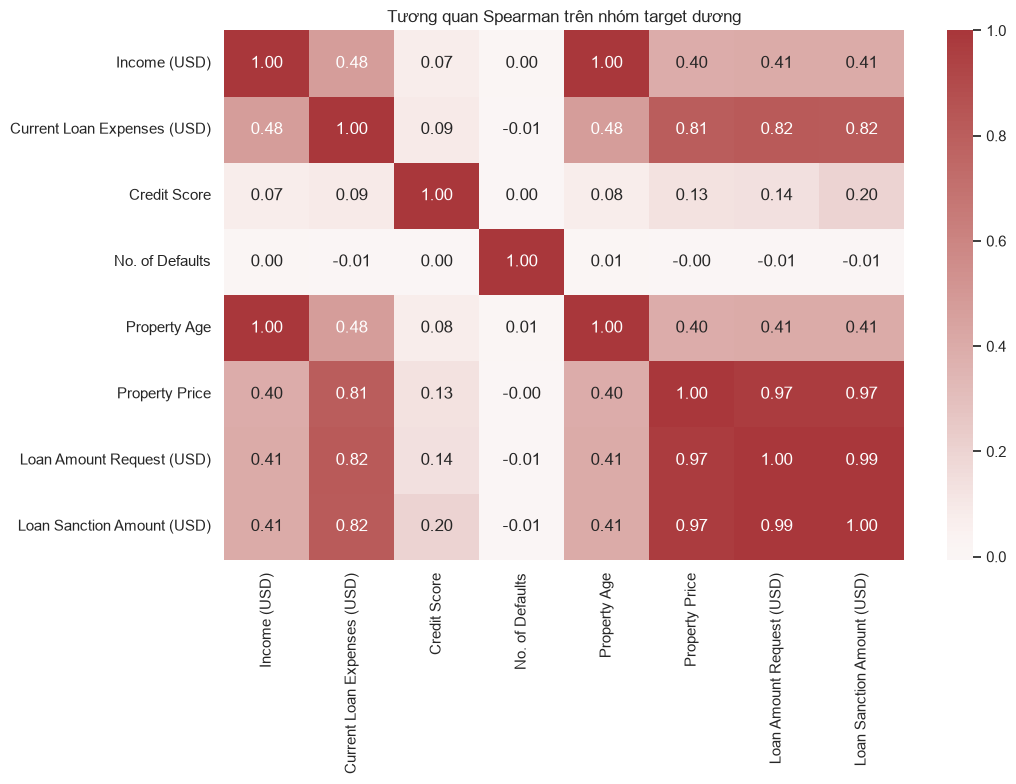

,n,credit_score,income,requested,property_price,sanctioned
RatioRounded,,,,,,
0.650,5053,700.962,"2,468.881","83,801.836","124,117.752","54,471.194"
0.700,8625,745.564,"2,841.799","89,051.510","131,518.255","62,336.057"
0.750,3852,807.538,"2,650.618","98,816.252","146,717.364","74,112.189"
0.800,3724,807.156,"2,693.327","99,256.891","147,507.392","79,405.513"
0.850,69,863.946,"2,917.631","104,449.616","158,472.928","88,782.174"
0.900,79,863.502,"2,471.519","103,138.394","161,841.177","92,824.554"
1.000,55,863.165,"2,969.179","110,551.428","170,845.794","110,551.428"


In [8]:
analysis_cols = [
    "Income (USD)", "Current Loan Expenses (USD)", "Credit Score",
    "No. of Defaults", "Property Age", "Property Price", REQUEST, TARGET,
]
corr = positive[analysis_cols].replace(-999, np.nan).corr(method="spearman")
plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
plt.title("Tương quan Spearman trên nhóm target dương")
plt.tight_layout()
plt.show()

ratio_profile = positive.groupby("RatioRounded").agg(
    n=(TARGET, "size"),
    credit_score=("Credit Score", "mean"),
    income=("Income (USD)", "mean"),
    requested=(REQUEST, "mean"),
    property_price=("Property Price", "mean"),
    sanctioned=(TARGET, "mean"),
).sort_index()
display(ratio_profile)

In [9]:
categorical = ["Income Stability", "Profession", "Type of Employment", "Location", "Property Location"]
profiles = []
for col in categorical:
    tmp = positive.groupby(col, dropna=False).agg(
        n=(TARGET, "size"),
        mean_target=(TARGET, "mean"),
        median_ratio=("SanctionRatio", "median"),
    ).reset_index()
    tmp.insert(0, "feature", col)
    tmp = tmp.rename(columns={col: "group"})
    profiles.append(tmp)
profile_table = pd.concat(profiles, ignore_index=True)
display(profile_table.sort_values(["feature", "n"], ascending=[True, False]))

,feature,group,n,mean_target,median_ratio
1,Income Stability,Low,17864,"66,178.549",0.700
0,Income Stability,High,2151,"63,953.295",0.750
2,Income Stability,NaN,1442,"65,076.291",0.700
30,Location,Semi-Urban,15445,"63,697.995",0.700
29,Location,Rural,3648,"62,964.465",0.700
31,Location,Urban,2364,"84,647.734",0.700
9,Profession,Working,11629,"62,447.735",0.700
4,Profession,Commercial associate,5763,"71,654.438",0.700
6,Profession,Pensioner,2323,"64,157.397",0.750
7,Profession,State servant,1738,"72,024.172",0.700


## 5. So sánh phân phối train và test ngoài

In [10]:
from scipy.stats import ks_2samp

shared_numeric = [c for c in df_external.select_dtypes(include=np.number).columns if c in df_raw.columns]
drift_rows = []
for col in shared_numeric:
    a = df_raw[col].replace(-999, np.nan).dropna()
    b = df_external[col].replace(-999, np.nan).dropna()
    stat, pvalue = ks_2samp(a, b)
    drift_rows.append({"feature": col, "ks_stat": stat, "p_value": pvalue, "train_mean": a.mean(), "test_mean": b.mean()})
drift = pd.DataFrame(drift_rows).sort_values("ks_stat", ascending=False)
display(drift)

max_ks = drift.iloc[0]
display(Markdown(f"Feature lệch nhất theo KS là **{max_ks['feature']}** với KS={max_ks['ks_stat']:.3f}. Giá trị nhỏ cho thấy train và test ngoài nhìn chung được sinh từ phân phối tương tự; p-value không được dùng đơn độc vì cỡ mẫu lớn."))

,feature,ks_stat,p_value,train_mean,test_mean
5,Credit Score,0.009,0.334,739.885,738.822
8,Property Age,0.008,0.448,"2,631.119","2,534.102"
0,Age,0.008,0.386,40.092,39.941
1,Income (USD),0.008,0.515,"2,630.574","2,536.995"
2,Loan Amount Request (USD),0.007,0.664,"88,826.334","88,859.077"
9,Property Type,0.007,0.682,2.460,2.472
3,Current Loan Expenses (USD),0.006,0.750,409.294,408.462
7,Property ID,0.006,0.820,501.935,501.024
6,No. of Defaults,0.004,0.972,0.194,0.190
4,Dependents,0.002,1.000,2.253,2.251


Feature lệch nhất theo KS là **Credit Score** với KS=0.009. Giá trị nhỏ cho thấy train và test ngoài nhìn chung được sinh từ phân phối tương tự; p-value không được dùng đơn độc vì cỡ mẫu lớn.

## 6. Kết luận EDA và giả thuyết cho mô hình

In [11]:
missing_top = quality[quality["missing_pct"] > 0].head(5)
display(Markdown(f"""
### Kết luận kỹ thuật

1. Population chính có {len(positive):,} hồ sơ target dương; target 0 và sentinel không được trộn vào regressor.
2. Target phụ thuộc rất mạnh vào số tiền yêu cầu và một số tỷ lệ policy rời rạc. Do đó phải so với rule baseline, không chỉ `DummyRegressor`.
3. Các cột thiếu nhiều nhất gồm {', '.join(missing_top.index.astype(str))}; imputation phải fit chỉ trên train.
4. `Customer ID`, `Name`, `Property ID` là định danh. `Gender` chỉ dùng audit fairness, không dùng production model mặc định.
5. `-999` xuất hiện cả ở target và feature; cần chuẩn hóa thành missing trước feature engineering.

### Hàm ý business

- LendScope là công cụ ước lượng **số tiền phê duyệt lịch sử cho hồ sơ đã pre-qualified**, không phải mô hình duyệt/từ chối.
- Nếu mô hình tốt chủ yếu nhờ `Loan Amount Request`, báo cáo phải nói rõ nó đang tái tạo policy lịch sử.
- Kết quả cần có policy cap và cảnh báo ngoài miền dữ liệu trước khi phục vụ qua API.
"""))


### Kết luận kỹ thuật

1. Population chính có 21,457 hồ sơ target dương; target 0 và sentinel không được trộn vào regressor.
2. Target phụ thuộc rất mạnh vào số tiền yêu cầu và một số tỷ lệ policy rời rạc. Do đó phải so với rule baseline, không chỉ `DummyRegressor`.
3. Các cột thiếu nhiều nhất gồm Type of Employment, Property Age, Income (USD), Dependents, Credit Score; imputation phải fit chỉ trên train.
4. `Customer ID`, `Name`, `Property ID` là định danh. `Gender` chỉ dùng audit fairness, không dùng production model mặc định.
5. `-999` xuất hiện cả ở target và feature; cần chuẩn hóa thành missing trước feature engineering.

### Hàm ý business

- LendScope là công cụ ước lượng **số tiền phê duyệt lịch sử cho hồ sơ đã pre-qualified**, không phải mô hình duyệt/từ chối.
- Nếu mô hình tốt chủ yếu nhờ `Loan Amount Request`, báo cáo phải nói rõ nó đang tái tạo policy lịch sử.
- Kết quả cần có policy cap và cảnh báo ngoài miền dữ liệu trước khi phục vụ qua API.
